# Handwriting recognition


## Data import and visualization


Import the MNIST train dataset ([https://en.wikipedia.org/wiki/MNIST_database](https://en.wikipedia.org/wiki/MNIST_database))


In [3]:
import matplotlib.pyplot as plt
import numpy as np

# This dataset is contained in the sample data directory of Google Colab online runtimes
data = np.genfromtxt("./mnist_train_small.csv", delimiter=",")
data.shape

(20000, 785)

Store the data in a matrix and the labels in a vector


In [4]:
labels_full = data[:, 0] #labels are first feature and everything else is data
A_full = data[:, 1:].transpose() #
labels_full.shape, A_full.shape

((20000,), (784, 20000))

Visualize the first 30 pictures with the corresponding labels


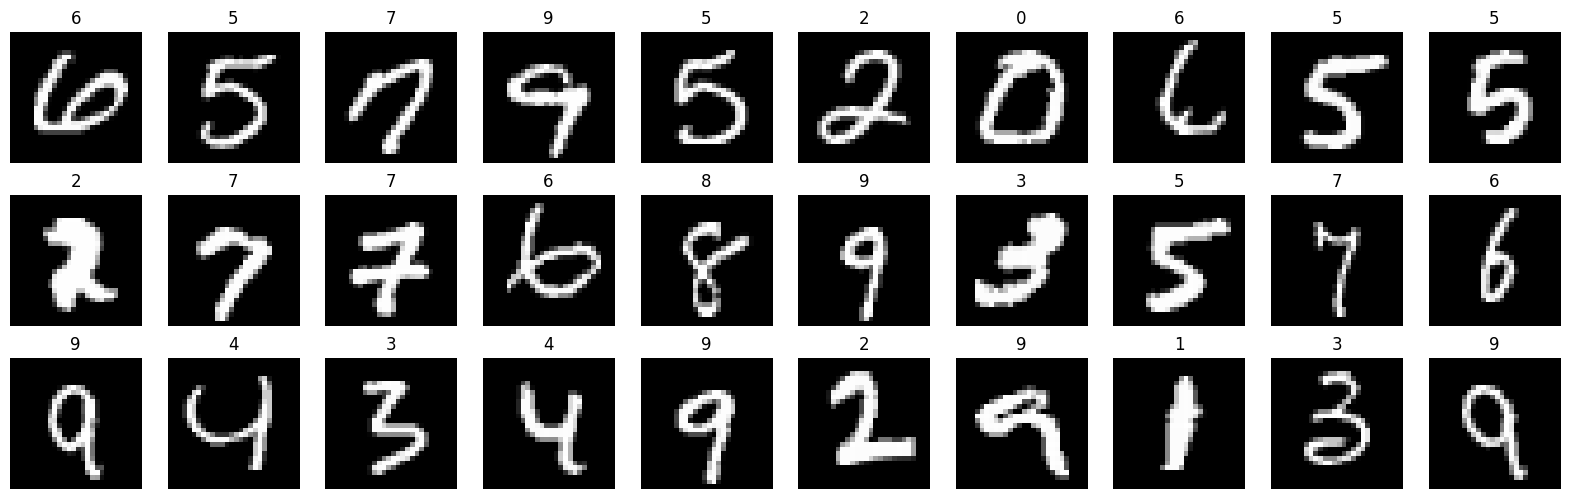

In [5]:
fig, axs = plt.subplots(ncols=10, nrows=3, figsize=(20, 6))
axs = axs.reshape((-1,))
for i in range(30):
    image_i = A_full[:, i].reshape((28, 28)) #reshaping the image as a square so that we can plot it
    axs[i].imshow(image_i, cmap="gray")
    axs[i].set_title(f"{labels_full[i]:.0f}")
    axs[i].axis("off")

Visualize the first 30 pictures corresponding the the digit "9"


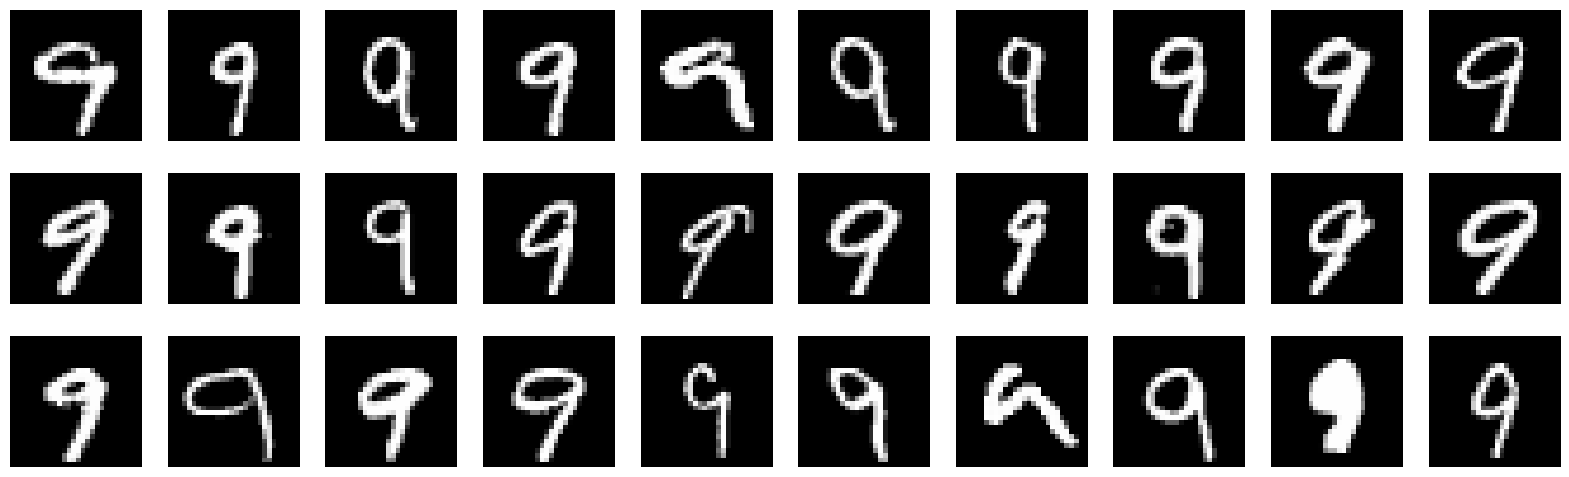

In [6]:
A_filtered = A_full[:, labels_full == 9]
fig, axs = plt.subplots(ncols=10, nrows=3, figsize=(20, 6))
axs = axs.reshape((-1,))
for i in range(30):
    image_i = A_filtered[:, i].reshape((28, 28))
    axs[i].imshow(image_i, cmap="gray")
    axs[i].axis("off")

### Classification of two digits (0 and 9)

We now focus on the digits 0 and 9 only. Build a reduced training dataset containing only images corresponding to these digits.


In [8]:
# HINT: use a bit-mask that is true when labels are 0 OR 9
digits = [0,9]
mask = np.logical_or( (labels_full == digits[0]), (labels_full == digits[1]))
A = A_full[:, mask]
labels = labels_full[mask]

A.shape

(784, 3985)

Plot the first 30 training images.


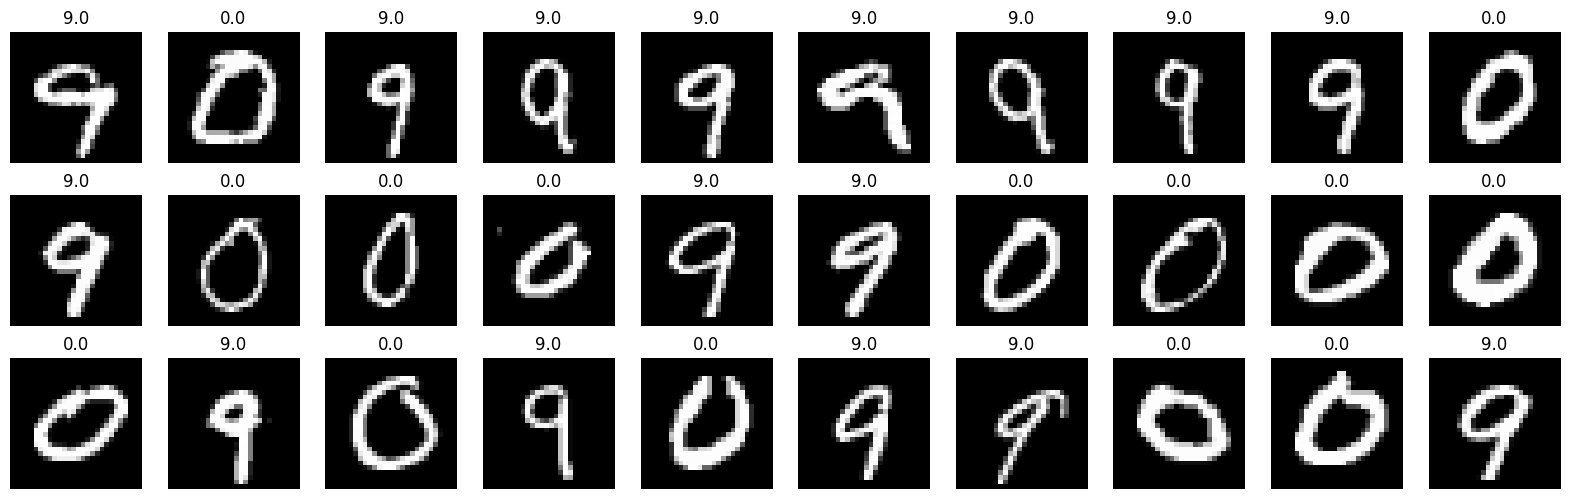

In [10]:
# FILL HERE
fig, axs = plt.subplots(ncols=10, nrows=3, figsize=(20, 6))
axs = axs.reshape((-1,))
for i in range(30):
    image_i = A[:, i].reshape((28, 28)) #reshaping the image as a square so that we can plot it
    axs[i].imshow(image_i, cmap="gray")
    axs[i].set_title(f"{labels[i]}")
    axs[i].axis("off")

Compute and visualize the average of the training data


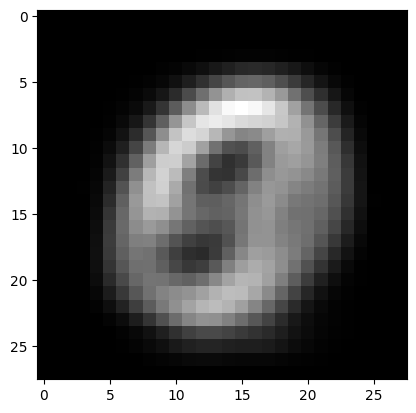

In [11]:
# FILL HERE
A_mean = np.mean(A, axis=1)

plt.imshow(A_mean.reshape((28,28)), cmap="gray") # A_mean is a vector, imshow takes a matrix so we reshape it


Perform PCA on the data (SVD on the zero mean data). Then, plot the trend of

- the singular values $\sigma_k$
- the cumulate fraction of singular values: $\frac{\sum_{i=1}^{k} \sigma_i}{\sum_{i=1}^{q} \sigma_i}$
- the fraction of the "explained variance": $\frac{\sum_{i=1}^{k} \sigma_i^2}{\sum_{i=1}^{q} \sigma_i^2}$


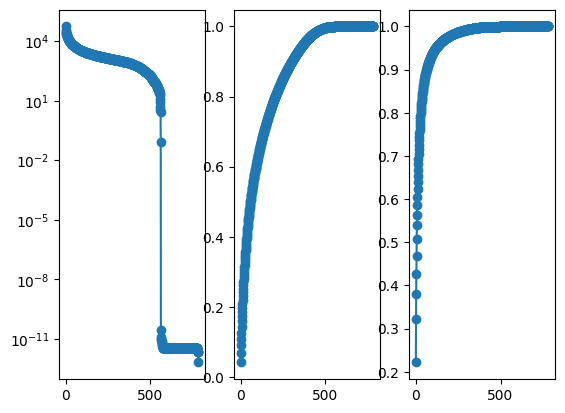

In [17]:
from numpy._core.fromnumeric import cumsum
A_bar = A - A_mean[:, None]
U, s, VT = np.linalg.svd(A_bar, full_matrices=False)

fig, axs = plt.subplots(nrows = 1, ncols = 3)
axs[0].semilogy(s, "o-")
axs[1].plot(np.cumsum(s) / np.sum(s), "o-")
axs[2]. plot(np.cumsum(s**2) / np.sum(s**2), "o-")

Visualize the first 30 principal axes (columns of $U$)


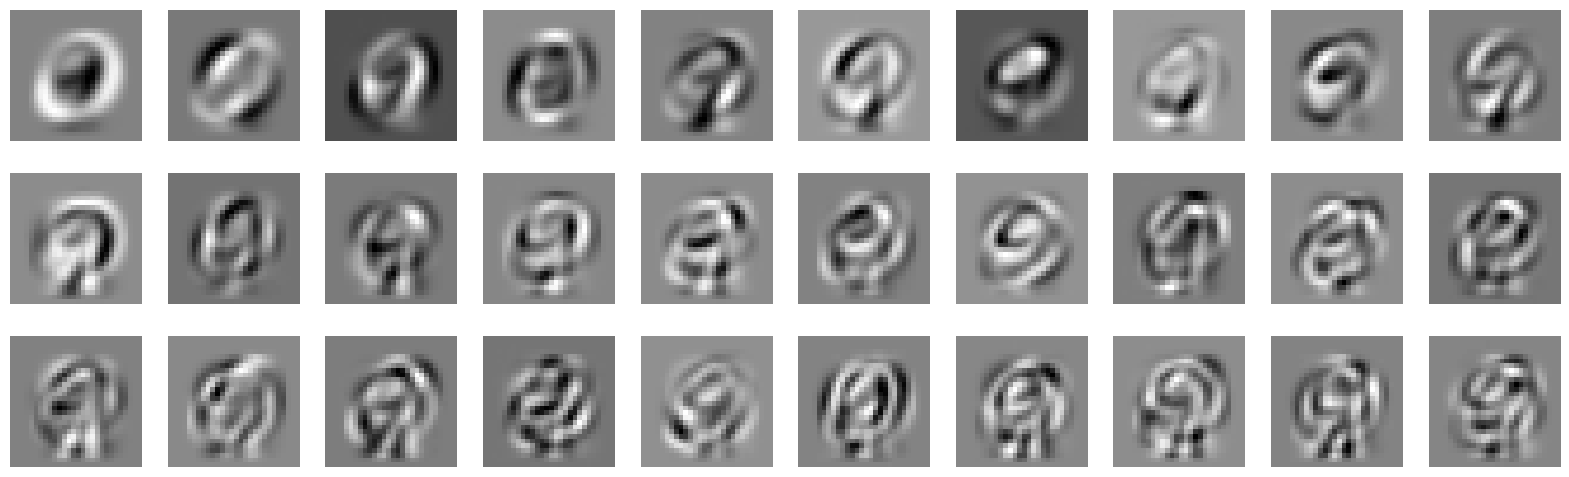

In [18]:
fig, axs = plt.subplots(ncols=10, nrows=3, figsize=(20, 6))
axs = axs.reshape((-1,))
for i in range(30):
    image_i = U[:, i].reshape((28, 28)) #reshaping the image as a square so that we can plot it
    axs[i].imshow(image_i, cmap="gray")
    axs[i].axis("off")

Compute the first two principal components corresponding to the first image


In [20]:
print(f"component1: {np.inner(A_bar[:, 0], U[:, 0])}")
print(f"component2: {np.inner(A_bar[:, 0], U[:, 1])}")

component1: -529.0964148086607
component2: -580.8608501624376


Define a matrix corresponding all the principal components of all the images ($U^T \bar{A}$) and check the result of the previous point

In [21]:
Phi = U.T @ A_bar
print(f"component 1: {Phi[0,0]}")
print(f"component 2: {Phi[1,0]}")

component 1: -529.0964148086608
component 2: -580.8608501624374


Create a scatterplot for the first 2 principal components of all the training images, grouped by label. Consider only the first 500 pictures.


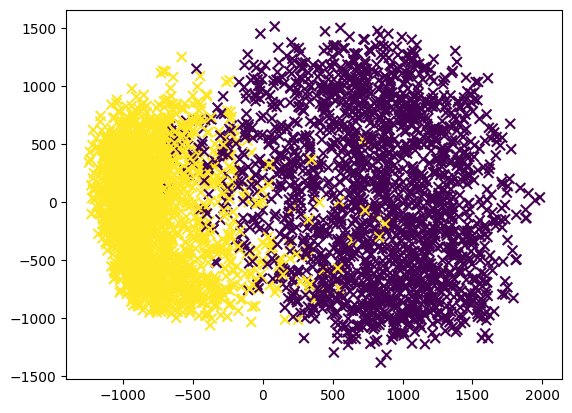

In [23]:
# naive, slow way
# for i in range(500):
#     # take the i-th sample and find the magnitude of its projection
#     # (that is, scalar prod) on the first and second principal axes
#     x = np.inner(A_bar[:, i], U[:, 0])
#     y = np.inner(A_bar[:, i], U[:, 1])
#     col = "r" if labels[i] == digits[0] else "b"
#     plt.scatter(x, y, marker="x", color=col, s=50)

# CHALLENGE: do the same of the above without a for loop
plt.scatter(Phi[0, :], Phi[1, :], c=labels, s = 50, marker='x')

## Make predictions on the test dataset
Define a classifier, by fixing a threshold on the first principal component. Namely, if a sample has the first principal component smaller than the threshold, it is in the first class, else it is in the second. Then, test the classifier on the MNIST test dataset. Compute the number of true/false positive/negative for both the digits (confusion matrix) and the accuracy of the classifier.


Choose a threshold by manual inspection, and plot the vertical line representing it

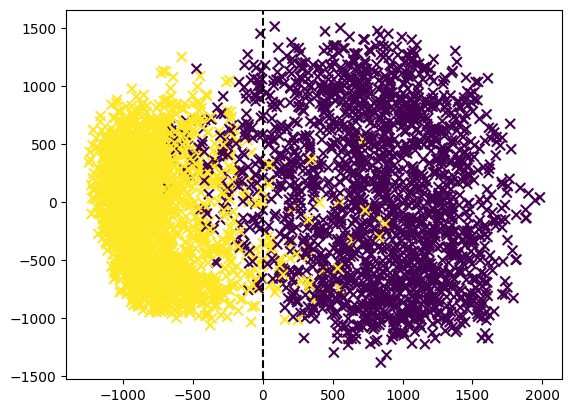

In [29]:
threshold = 0.0
plt.scatter(Phi[0, :], Phi[1, :], marker="x", c=labels, s=50)
plt.axvline(threshold, color="k", linestyle="--")

Load the test dataset

In [31]:
data_test = np.genfromtxt("./mnist_test.csv", delimiter=",")
data_test.shape
labels_test = data_test[:, 0]
A_test = data_test[:, 1:].transpose()

In [34]:
mask_test = (labels_test == digits[0]) | (labels_test== digits[1])
A_test = A_test[:, mask_test]
labels_test = labels_test[mask_test]

Extract the pictures of 0s and 9s

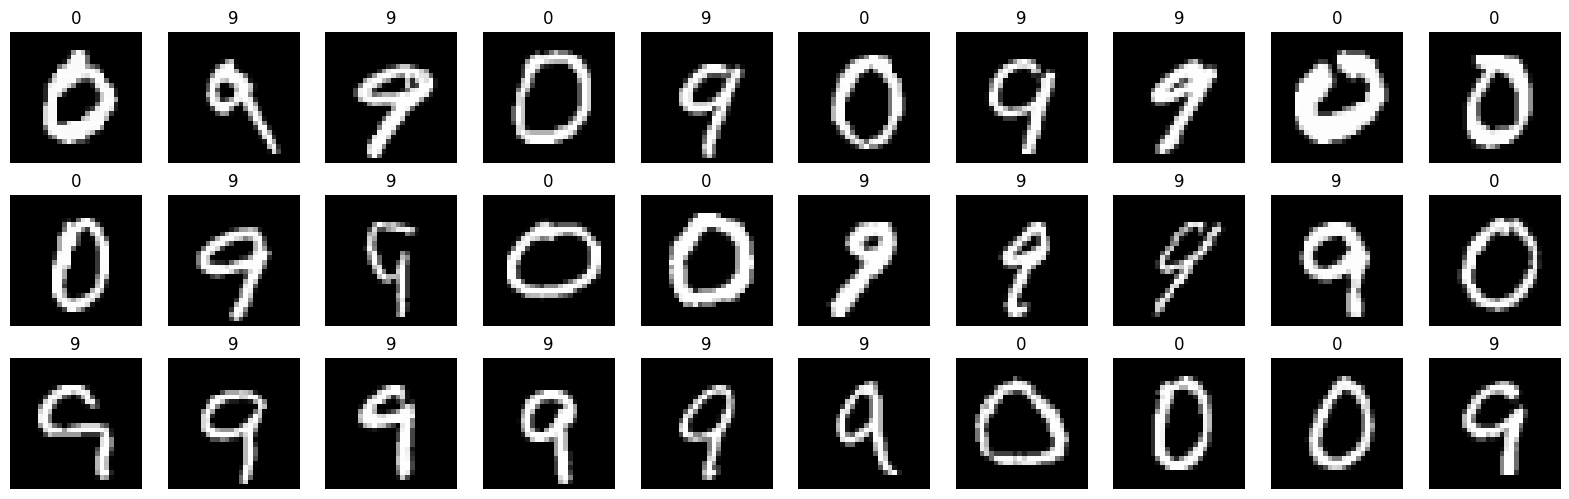

In [36]:
fig, axs = plt.subplots(ncols=10, nrows=3, figsize=(20, 6))
axs = axs.reshape((-1,))
for i in range(30):
    image_i = A_test[:, i].reshape((28, 28)) #reshaping the image as a square so that we can plot it
    axs[i].imshow(image_i, cmap="gray")
    axs[i].set_title(f"{labels_test[i]:.0f}")
    axs[i].axis("off")

Plot the first 500 samples transformed following the **TRAINING** data principal components.

In [37]:
Phi_test = U.T @ (A_test - A_mean[:, None]) #mean of train since it is estimation of data

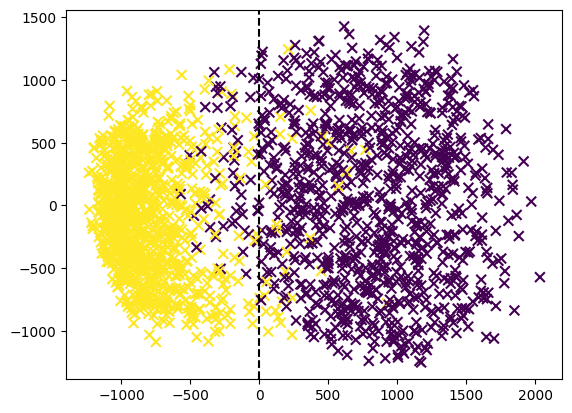

In [38]:
threshold = 0.0
plt.scatter(Phi_test[0, :], Phi_test[1, :], marker="x", c=labels_test, s=50)
plt.axvline(threshold, color="k", linestyle="--")

Compute the confusion matrix, namely how many 0s are classified as 0s, how many 0s are classified as 9s, how many 9s are classified as 0s and how many 9s are classified as 9s.

In [42]:
PC_1 = Phi_test[0, :]
labels_predict = np.where(PC_1 > threshold, digits[0], digits[1])

true_0 = np.sum((labels_test == 0) & (labels_predict==0))
true_9 = np.sum((labels_test == 9) & (labels_predict==9))
false_0 = np.sum((labels_test == 0) & (labels_predict==9))
false_9 = np.sum((labels_test == 9) & (labels_predict==0))

print(true_0)
print(true_9)
print(false_0)
print(false_9)

accuracy = (true_0 + true_9)/ (true_0+true_9+false_0+false_9)
print(accuracy)


927
979
53
30
0.9582704876822524


You can do the same more compactly with scikit learn


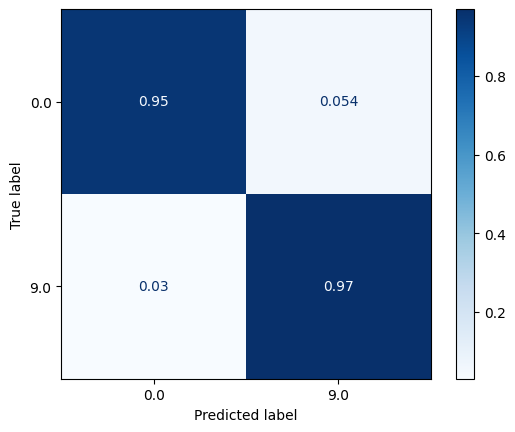

In [44]:
from sklearn import metrics

cm_display = metrics.ConfusionMatrixDisplay.from_predictions(
    labels_test, labels_predict, cmap=plt.cm.Blues, normalize="true"
)